In [16]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline

In [17]:
X, _ = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=42)

In [18]:
X.shape

(1000, 2)

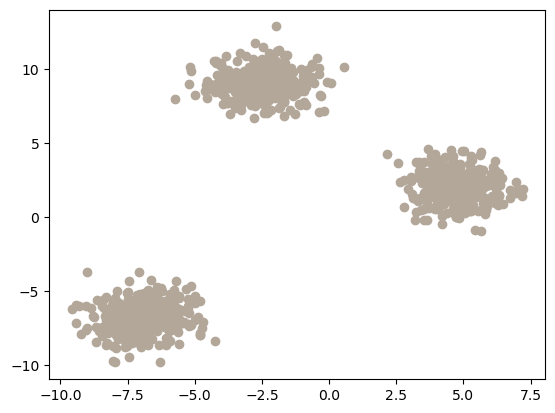

In [19]:
plt.scatter(X[:, 0], X[:, 1], c="#B3A79A", cmap="rainbow")
plt.show()

In [20]:
# Standardize the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# ignore the y_train and t_test because this is unsupervised learning
X_scaled = scaler.fit_transform(X)

In [21]:
from sklearn.cluster import KMeans

In [22]:
## elbow method to find the optimal number of clusters

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

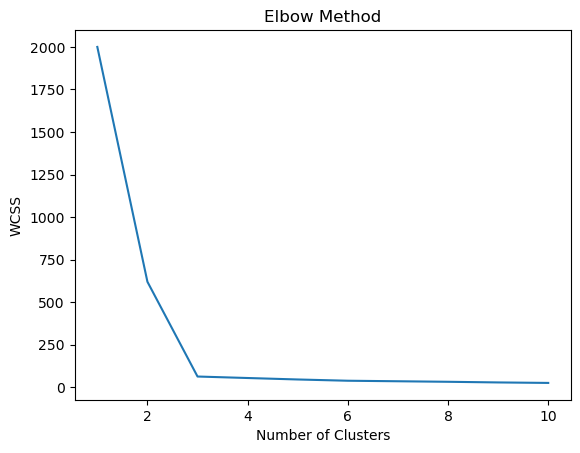

In [23]:
# plot the elbow method graph

plt.plot(range(1, 11), wcss)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [26]:
# create 3 clusters

kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)

x_pred = kmeans.fit_predict(X_scaled)

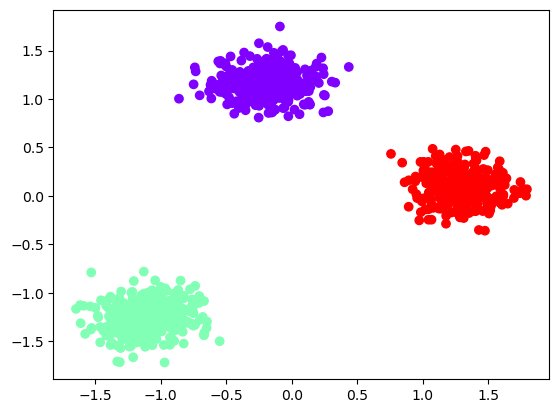

In [35]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=x_pred, cmap="rainbow")
plt.show()

In [36]:
# Validating the k value

# kneelocator
from kneed import KneeLocator

kl = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")

# it is returning 3, so our 3 clusters choice is good
kl.elbow

3

In [41]:
# silhouette scoring

from sklearn.metrics import silhouette_score

# where the silhouette score is maximum, that is the optimal number of clusters
silhouette_coefficient = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_coefficient.append(score)

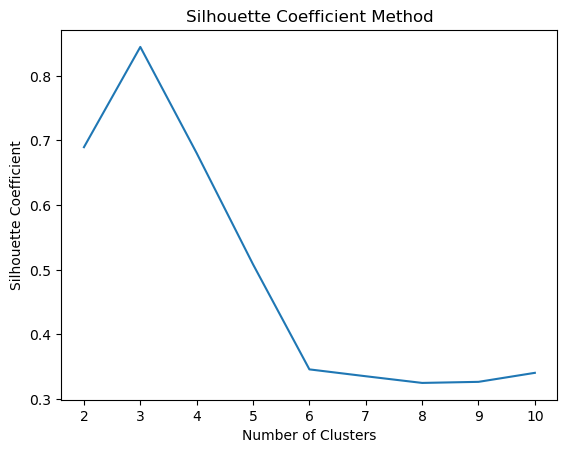

In [42]:
plt.plot(range(2, 11), silhouette_coefficient)

plt.title("Silhouette Coefficient Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()